In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the house price prediction dataset
df = pd.read_csv(
    r"C:\Users\user\Documents\AnalytycsLab week 4 (task 1 and 2)\House Prediction (task 1)\House prediction data set\House Price Prediction Dataset.csv"
)

# --- Basic overview ---
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())
print("\nDataset info:")
df.info()
print("\nDuplicate rows:", df.duplicated().sum())
print("\nMissing values:\n", df.isnull().sum())
print("\nSummary statistics (numeric columns):\n", df.describe())

# Categorical column counts
for col in ["Location", "Condition", "Garage"]:
    print(f"\n{col} value counts:\n", df[col].value_counts())


Shape: (2000, 10)

Data types:
 Id            int64
Area          int64
Bedrooms      int64
Bathrooms     int64
Floors        int64
YearBuilt     int64
Location     object
Condition    object
Garage       object
Price         int64
dtype: object

First 5 rows:
    Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  -

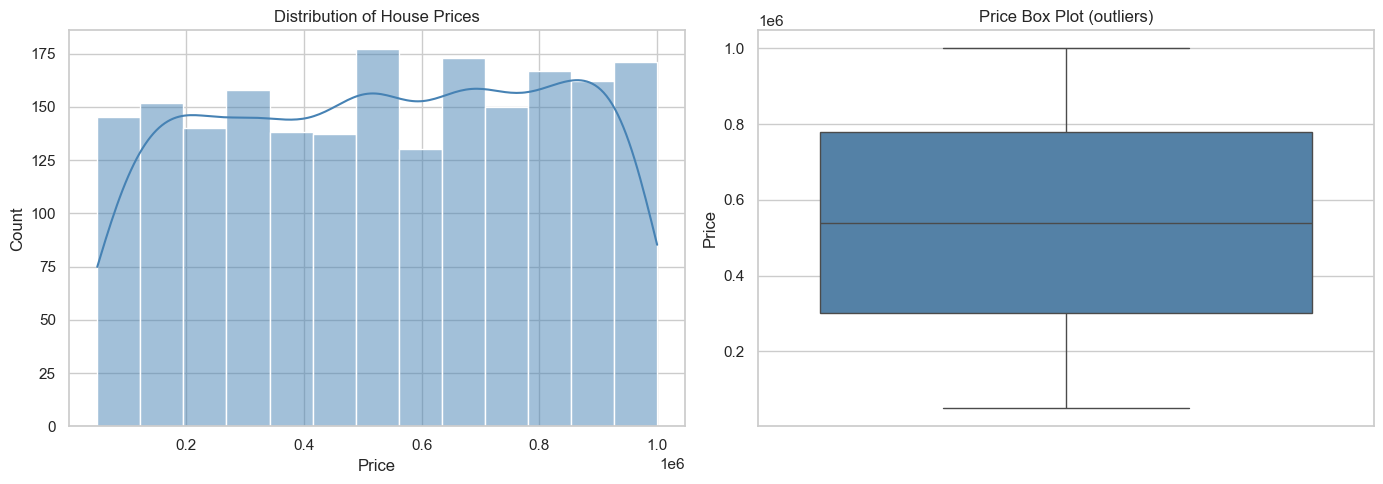

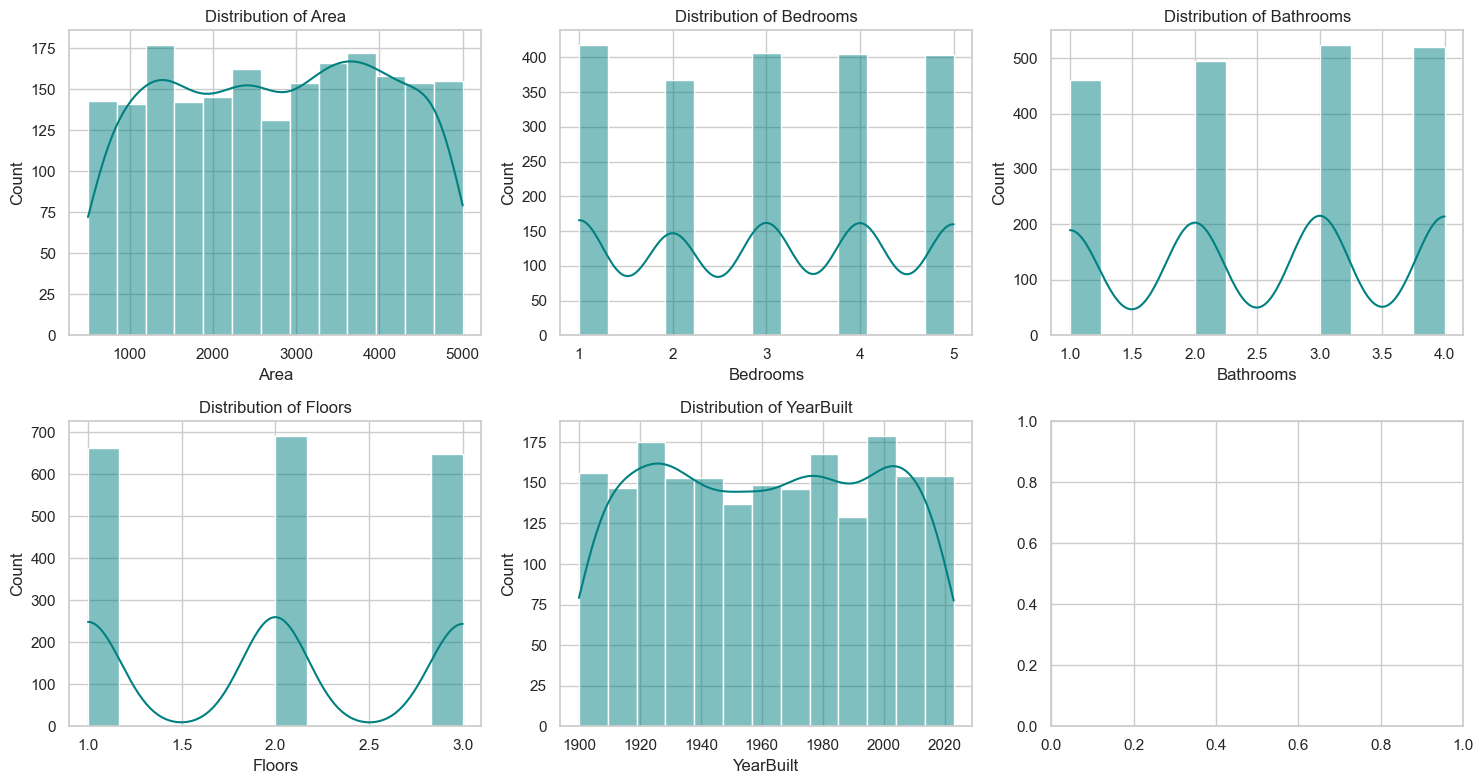

In [31]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

numeric_cols = ["Area", "Bedrooms", "Bathrooms", "Floors", "YearBuilt", "Price"]

# 1. Distribution of the target variable (Price)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["Price"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of House Prices")
axes[0].set_xlabel("Price")

sns.boxplot(y=df["Price"], ax=axes[1], color="steelblue")
axes[1].set_title("Price Box Plot (outliers)")
axes[1].set_ylabel("Price")
plt.tight_layout()
plt.show()

# 2. Distributions of numeric predictors
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for ax, col in zip(axes, numeric_cols[:-1]):
    sns.histplot(df[col], kde=True, ax=ax, color="teal")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_14596\2388898673.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax, palette="muted")
C:\Users\user\AppData\Local\Temp\ipykernel_14596\2388898673.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax, palette="muted")
C:\Users\user\AppData\Local\Temp\ipykernel_14596\2388898673.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax, palette="muted")


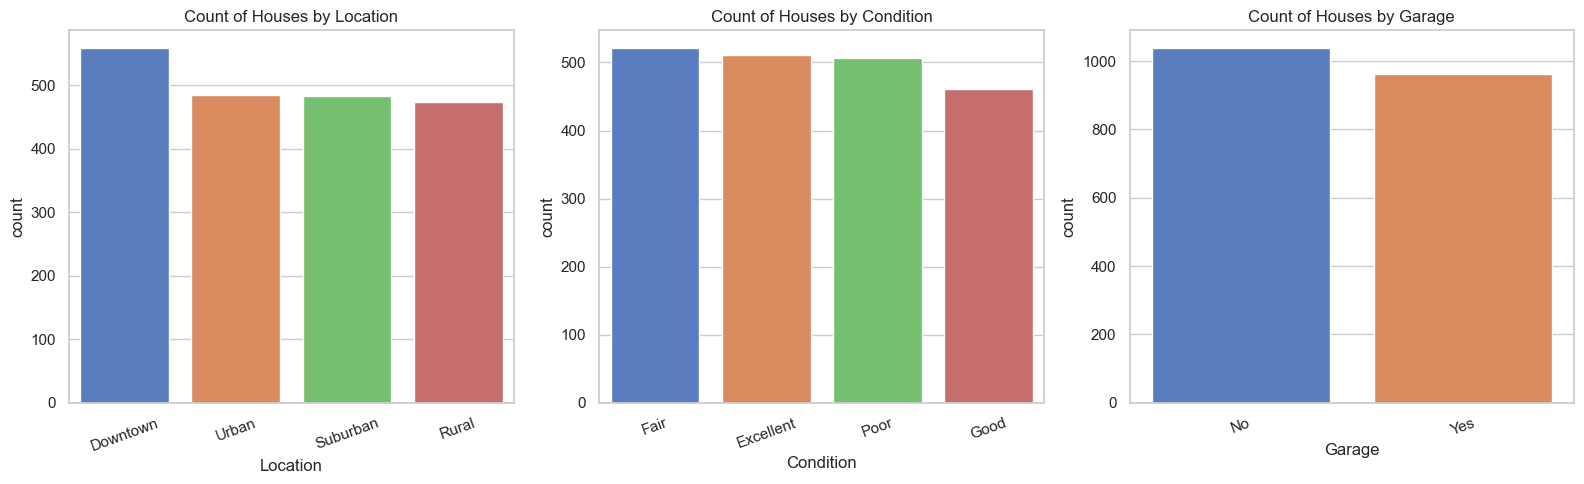

C:\Users\user\AppData\Local\Temp\ipykernel_14596\2388898673.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="Price", ax=ax, palette="Set2")
C:\Users\user\AppData\Local\Temp\ipykernel_14596\2388898673.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="Price", ax=ax, palette="Set2")
C:\Users\user\AppData\Local\Temp\ipykernel_14596\2388898673.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="Price", ax=ax, palette="Set2")


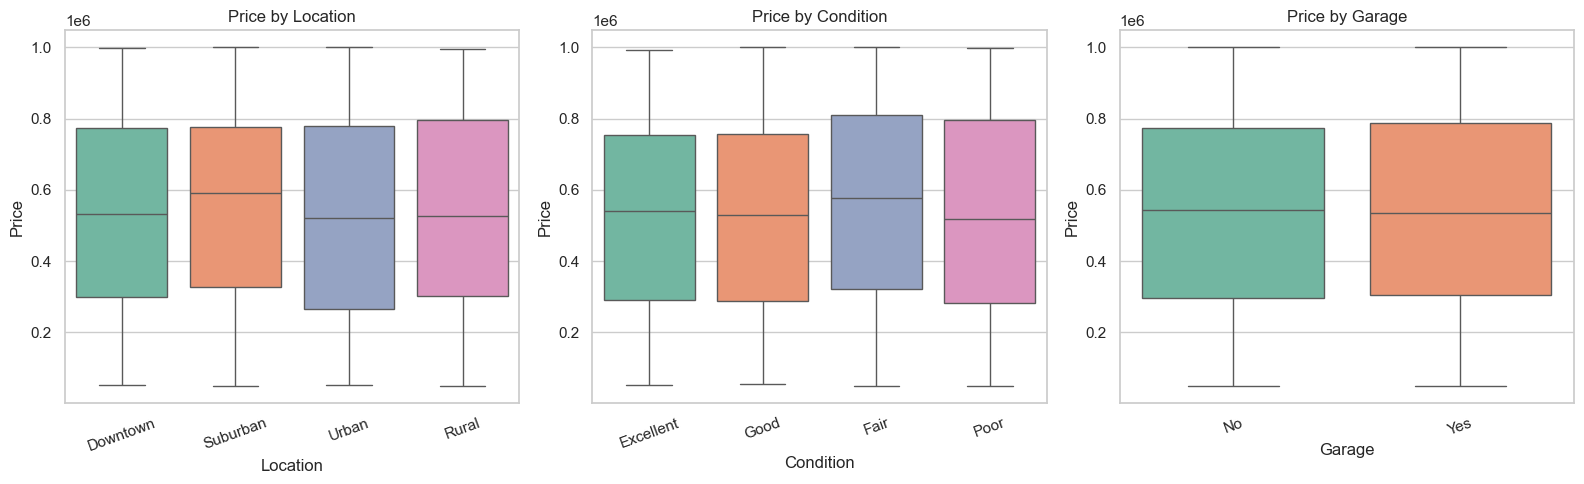

In [32]:
# 3. Categorical feature counts
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ["Location", "Condition", "Garage"]):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, palette="muted")
    ax.set_title(f"Count of Houses by {col}")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

# 4. Price by categorical features
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ["Location", "Condition", "Garage"]):
    sns.boxplot(data=df, x=col, y="Price", ax=ax, palette="Set2")
    ax.set_title(f"Price by {col}")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

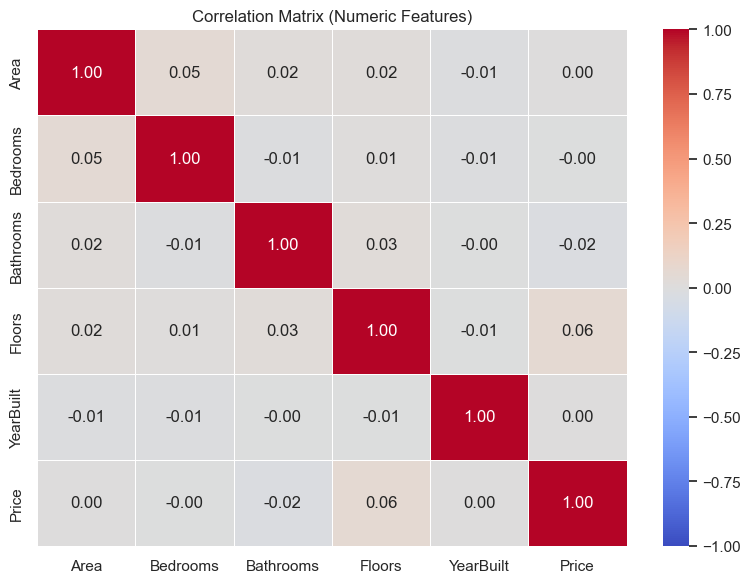

Correlations with Price:
 Price        1.000000
Floors       0.055890
YearBuilt    0.004845
Area         0.001542
Bedrooms    -0.003471
Bathrooms   -0.015737
Name: Price, dtype: float64
This proves our Initial statement of corelation. 


In [33]:
# 5. Correlation heatmap (numeric features only)
corr = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()

print("Correlations with Price:\n", corr["Price"].sort_values(ascending=False))

print ("This proves our Initial statement of corelation. ")

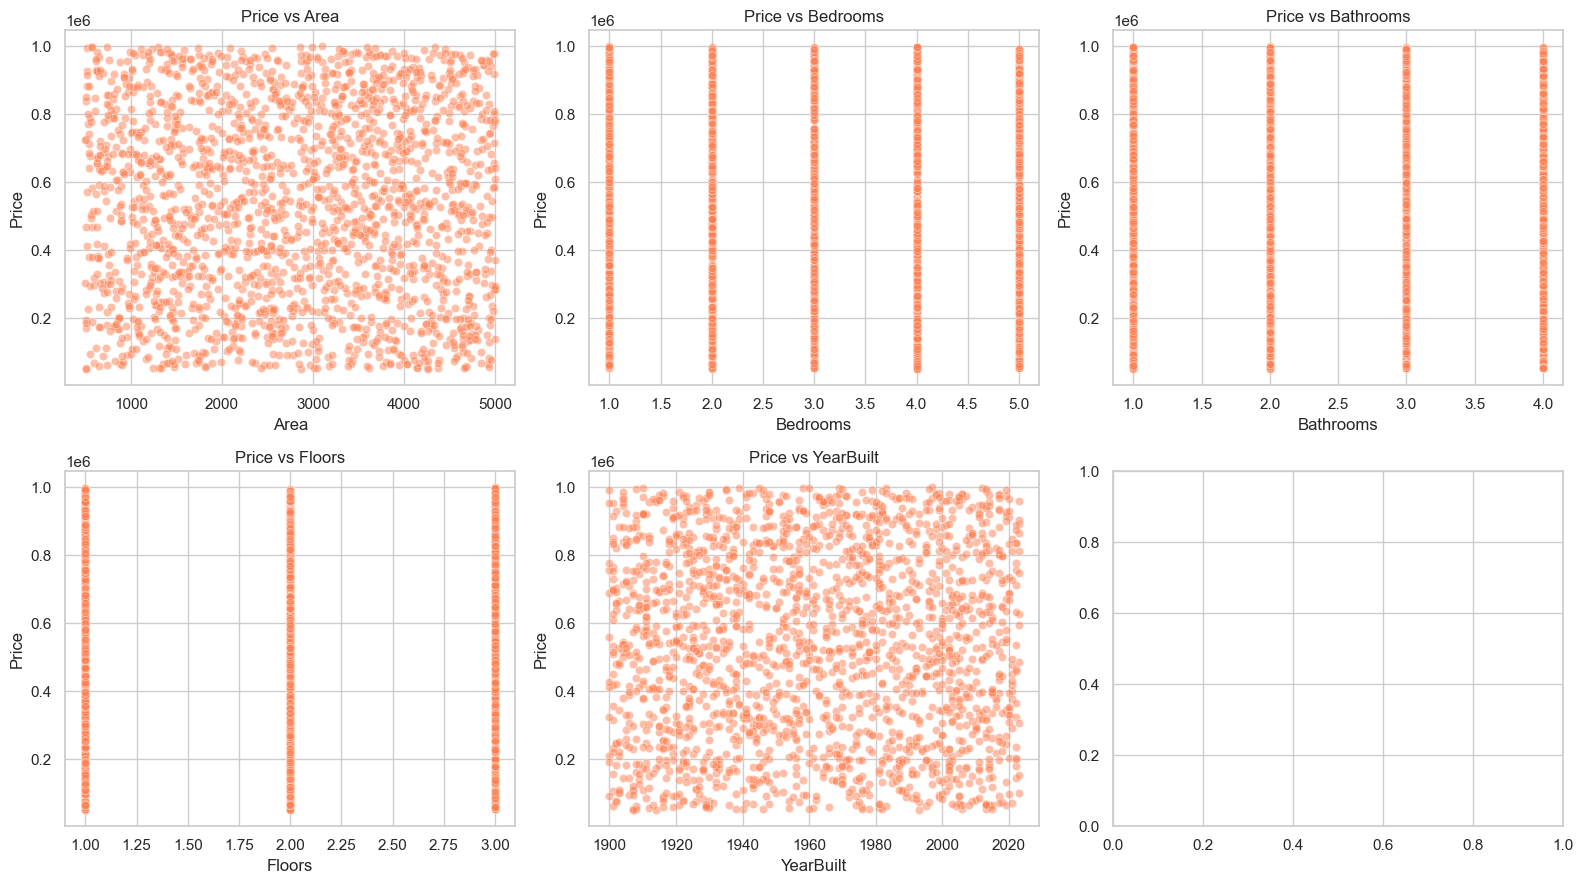

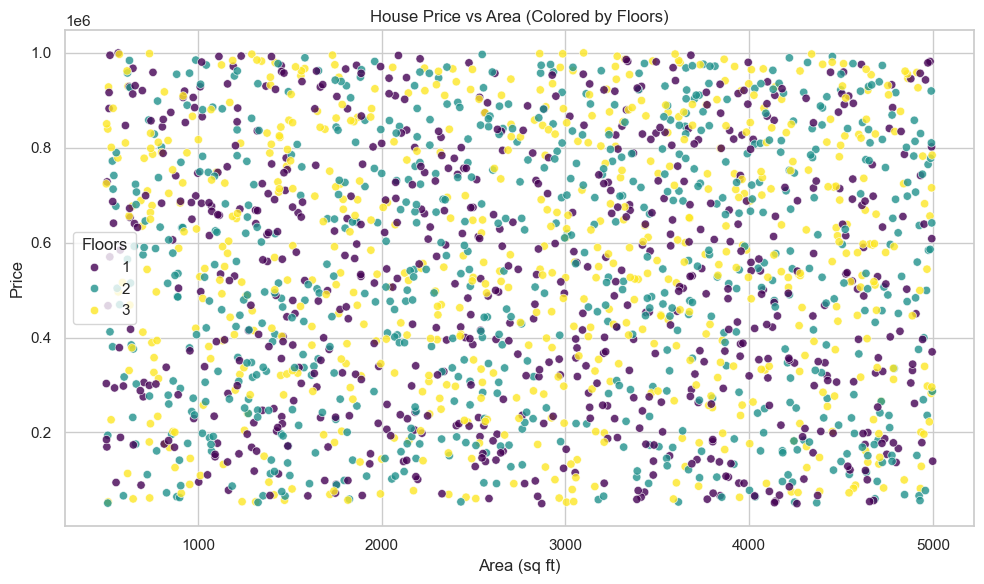

In [34]:
# 6. Scatter plots: numeric features vs Price
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
for ax, col in zip(axes, numeric_cols[:-1]):
    sns.scatterplot(data=df, x=col, y="Price", alpha=0.5, ax=ax, color="coral")
    ax.set_title(f"Price vs {col}")
plt.tight_layout()
plt.show()

# Area vs Price with floors as hue (useful for spotting patterns by floor count)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Area", y="Price", hue="Floors", palette="viridis", alpha=0.8)
plt.title("House Price vs Area (Colored by Floors)")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")
plt.legend(title="Floors")
plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_14596\991726675.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price.index, y=avg_price.values, ax=ax, palette="Blues_d")
C:\Users\user\AppData\Local\Temp\ipykernel_14596\991726675.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price.index, y=avg_price.values, ax=ax, palette="Blues_d")
C:\Users\user\AppData\Local\Temp\ipykernel_14596\991726675.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price.index, y=avg_price.values, ax=ax, palette="Blues_d")


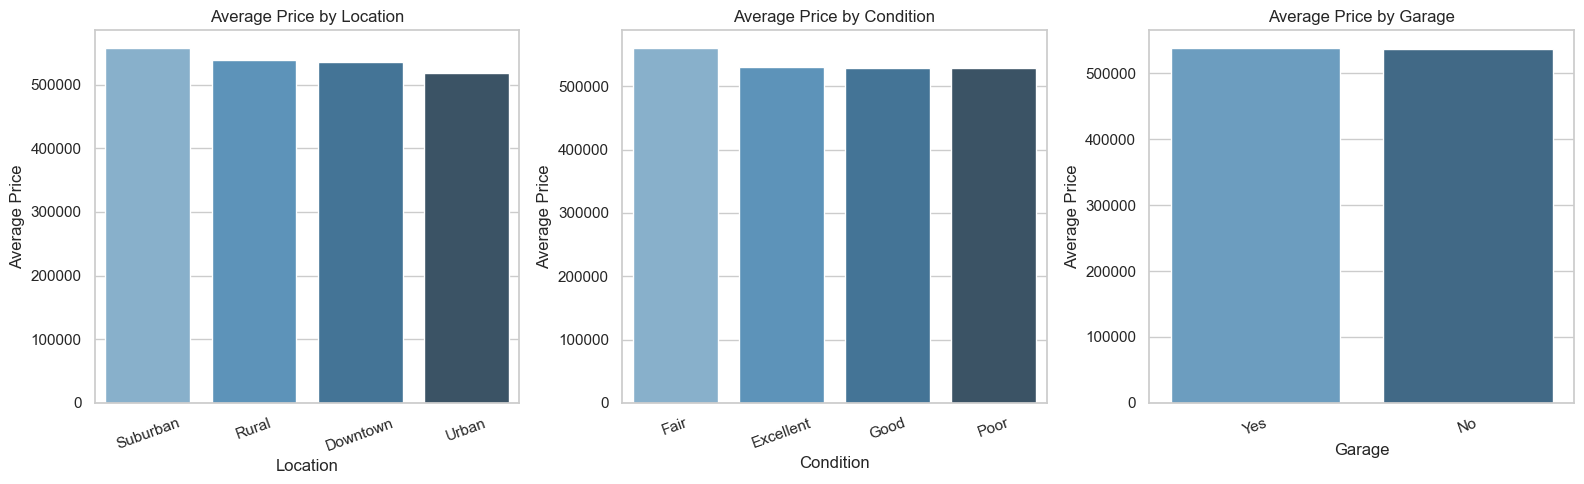

In [35]:
# 7. Average price by category (helps compare groups visually)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ["Location", "Condition", "Garage"]):
    avg_price = df.groupby(col)["Price"].mean().sort_values(ascending=False)
    sns.barplot(x=avg_price.index, y=avg_price.values, ax=ax, palette="Blues_d")
    ax.set_title(f"Average Price by {col}")
    ax.set_ylabel("Average Price")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

In [36]:
# 8. Key EDA takeaways
print("=== EDA Summary ===")
print(f"• Dataset: {df.shape[0]} houses, {df.shape[1]} columns")
print(f"• No missing values or duplicate rows")
print(f"• Price range: ${df['Price'].min():,.0f} – ${df['Price'].max():,.0f} (mean: ${df['Price'].mean():,.0f})")
print(f"• Numeric features show very weak linear correlation with Price")
print(f"  (strongest: Floors = {df[numeric_cols].corr()['Price']['Floors']:.3f})")
print(f"• Categorical variables (Location, Condition, Garage) may be more useful for modelling")
print(f"• Price appears roughly uniform across numeric ranges — consider non-linear models or feature engineering")

=== EDA Summary ===
• Dataset: 2000 houses, 10 columns
• No missing values or duplicate rows
• Price range: $50,005 – $999,656 (mean: $537,677)
• Numeric features show very weak linear correlation with Price
  (strongest: Floors = 0.056)
• Categorical variables (Location, Condition, Garage) may be more useful for modelling
• Price appears roughly uniform across numeric ranges — consider non-linear models or feature engineering


# Machine Learning — House Price Prediction

Steps: preprocess features → train/test split → train models → evaluate and compare performance.

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Step 1: Prepare features and target ---
# Drop Id (not a predictive feature)
df_ml = df.drop(columns=["Id"]).copy()

X = df_ml.drop(columns=["Price"])
y = df_ml["Price"]

numeric_features = ["Area", "Bedrooms", "Bathrooms", "Floors", "YearBuilt"]
categorical_features = ["Location", "Condition", "Garage"]

# One-hot encode categoricals; keep numeric columns as-is for scaling
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=False)

print("Feature matrix shape:", X_encoded.shape)
print("Target shape:", y.shape)
print("\nEncoded feature columns:\n", list(X_encoded.columns))

Feature matrix shape: (2000, 15)
Target shape: (2000,)

Encoded feature columns:
 ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location_Downtown', 'Location_Rural', 'Location_Suburban', 'Location_Urban', 'Condition_Excellent', 'Condition_Fair', 'Condition_Good', 'Condition_Poor', 'Garage_No', 'Garage_Yes']


In [38]:
# --- Step 2: Train / test split (80% train, 20% test) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Training set: 1600 samples
Test set:     400 samples


In [39]:
# --- Step 3: Build and train models ---
# Scale numeric features inside each pipeline for fair comparison

preprocessor = ColumnTransformer(
    transformers=[("scaler", StandardScaler(), numeric_features)],
    remainder="passthrough",
)

models = {
    "Linear Regression": Pipeline([
        ("preprocess", preprocessor),
        ("model", LinearRegression()),
    ]),
    "Ridge Regression": Pipeline([
        ("preprocess", preprocessor),
        ("model", Ridge(alpha=1.0, random_state=42)),
    ]),
    "Random Forest": Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(n_estimators=200, random_state=42)),
    ]),
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R²": r2}

results_df = pd.DataFrame(results).T.round(2)
print("Model Performance on Test Set:\n")
print(results_df)

best_model = results_df["R²"].idxmax()
print(f"\nBest model (by R²): {best_model}")

Model Performance on Test Set:

                         MAE           MSE       RMSE    R²
Linear Regression  243597.70  7.832100e+10  279858.89 -0.01
Ridge Regression   243243.24  7.832112e+10  279859.10 -0.01
Random Forest      253351.55  8.601835e+10  293288.86 -0.11

Best model (by R²): Linear Regression


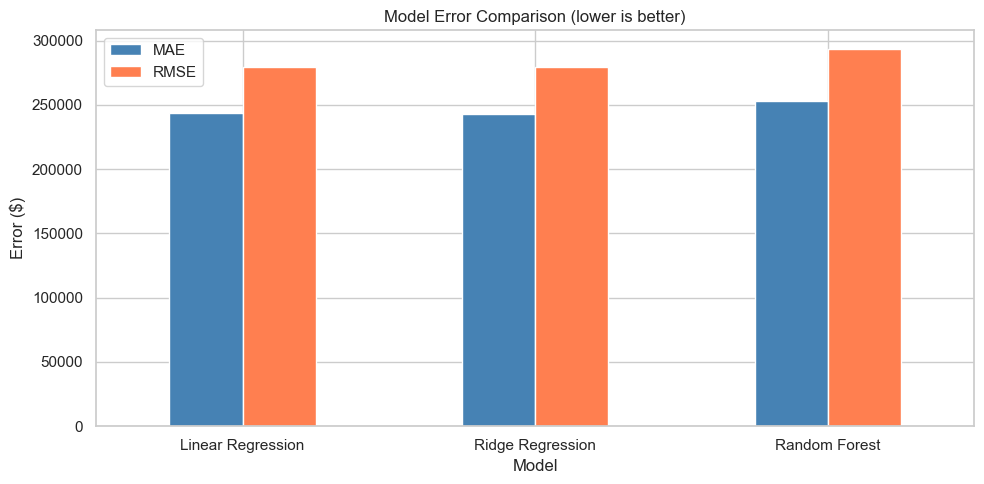

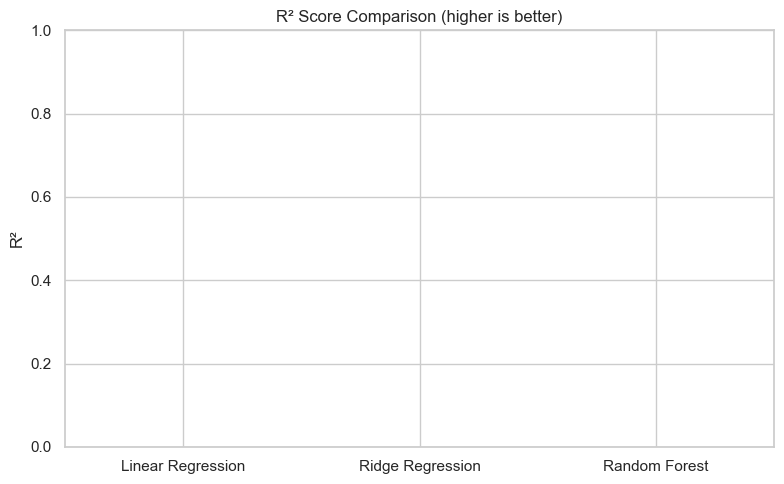

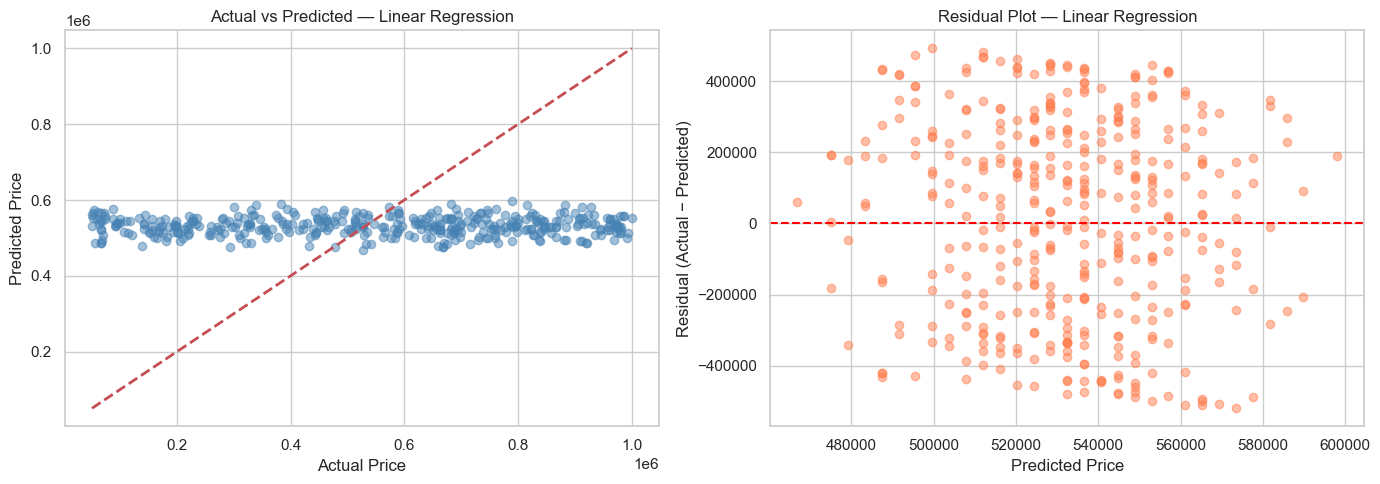

In [40]:
# --- Step 4: Visualise model performance ---

# 4a. Compare metrics across models
fig, ax = plt.subplots(figsize=(10, 5))
results_df[["MAE", "RMSE"]].plot(kind="bar", ax=ax, color=["steelblue", "coral"])
ax.set_title("Model Error Comparison (lower is better)")
ax.set_ylabel("Error ($)")
ax.set_xlabel("Model")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
results_df["R²"].plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("R² Score Comparison (higher is better)")
ax.set_ylabel("R²")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

# 4b. Actual vs Predicted (best model)
y_pred_best = predictions[best_model]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_best, alpha=0.5, color="steelblue")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].set_title(f"Actual vs Predicted — {best_model}")

residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.5, color="coral")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted Price")
axes[1].set_ylabel("Residual (Actual − Predicted)")
axes[1].set_title(f"Residual Plot — {best_model}")

plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_14596\1852960678.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance.values, y=importance.index, palette="viridis")


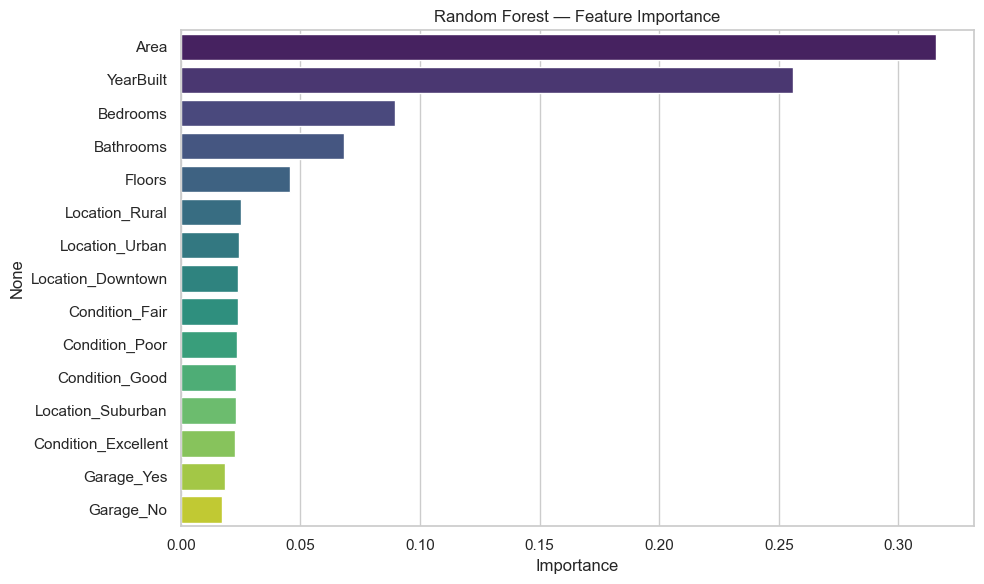

Top 5 most important features:
 Area         0.315844
YearBuilt    0.255849
Bedrooms     0.089495
Bathrooms    0.068285
Floors       0.045529
dtype: float64


In [41]:
# --- Step 5: Feature importance (Random Forest) ---
rf_model = models["Random Forest"].named_steps["model"]
feature_names = numeric_features + [c for c in X_encoded.columns if c not in numeric_features]

importance = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importance.values, y=importance.index, palette="viridis")
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 5 most important features:\n", importance.head())

In [42]:
# --- Step 6: Sample prediction on a new house ---
sample = pd.DataFrame([{
    "Area": 2500,
    "Bedrooms": 3,
    "Bathrooms": 2,
    "Floors": 2,
    "YearBuilt": 2005,
    "Location": "Suburban",
    "Condition": "Good",
    "Garage": "Yes",
}])

sample_encoded = pd.get_dummies(sample, columns=categorical_features, drop_first=False)
sample_encoded = sample_encoded.reindex(columns=X_encoded.columns, fill_value=0)

best_pipeline = models[best_model]
predicted_price = best_pipeline.predict(sample_encoded)[0]

print("Sample house details:")
print(sample.T)
print(f"\nPredicted price ({best_model}): ${predicted_price:,.0f}")

Sample house details:
                  0
Area           2500
Bedrooms          3
Bathrooms         2
Floors            2
YearBuilt      2005
Location   Suburban
Condition      Good
Garage          Yes

Predicted price (Linear Regression): $540,672


In [43]:
# --- ML Summary ---
print("=== Machine Learning Summary ===")
print(f"• Features used: {X_encoded.shape[1]} (after one-hot encoding)")
print(f"• Train/test split: 80% / 20%")
print(f"• Models trained: Linear Regression, Ridge Regression, Random Forest")
print(f"• Best model: {best_model} (R² = {results_df.loc[best_model, 'R²']:.2f}, RMSE = ${results_df.loc[best_model, 'RMSE']:,.0f})")
print(f"• Weak numeric correlations from EDA explain why R² may stay low — tree-based models capture non-linear patterns better")

=== Machine Learning Summary ===
• Features used: 15 (after one-hot encoding)
• Train/test split: 80% / 20%
• Models trained: Linear Regression, Ridge Regression, Random Forest
• Best model: Linear Regression (R² = -0.01, RMSE = $279,859)
• Weak numeric correlations from EDA explain why R² may stay low — tree-based models capture non-linear patterns better
